# Descriptive Statistics(Part-2)

In [1]:
# setup libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# create dataset
data=[10,12,15,20,22,25,28,30,35]
data

[10, 12, 15, 20, 22, 25, 28, 30, 35]

In [3]:
# Quantiles
np.quantile(data,0.25)

np.float64(15.0)

In [9]:
# Percentiles
np.percentile(data,50)

np.float64(22.0)

In [10]:
## calculate everything at once
np.percentile(data,[25,50,75])

array([15., 22., 28.])

In [17]:
# Five-Number Summary
minimum=np.min(data)
q1=np.percentile(data,25)
median=np.median(data)
q3=np.percentile(data,75)
maximum=np.max(data)

print('Minimum: ',minimum)
print('Q1: ',q1)
print('Median: ',median)
print('Q3: ',q3)
print('Maximum: ',maximum)

Minimum:  10
Q1:  15.0
Median:  22.0
Q3:  28.0
Maximum:  35


In [18]:
# or this way it can be written
five_number_summary = [
    np.min(data),
    np.percentile(data, 25),
    np.median(data),
    np.percentile(data, 75),
    np.max(data)
]

five_number_summary


[np.int64(10),
 np.float64(15.0),
 np.float64(22.0),
 np.float64(28.0),
 np.int64(35)]

In [20]:
# IQR(InterQuartile Range)
IQR= q3-q1
IQR

np.float64(13.0)

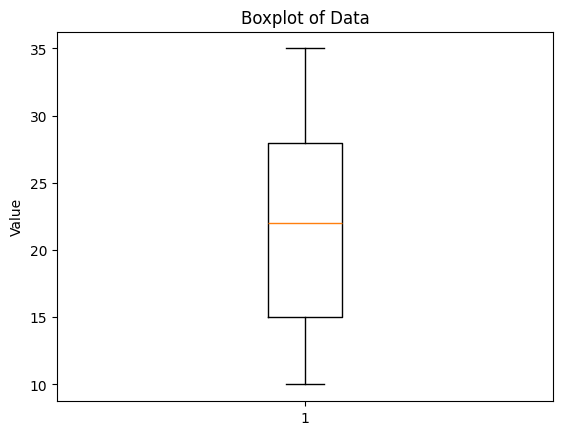

In [23]:
# Boxplots
plt.boxplot(data)
plt.title("Boxplot of Data")
plt.ylabel("Value")
plt.show()

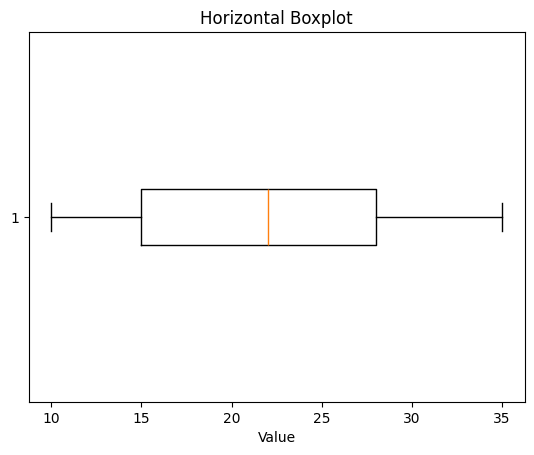

In [25]:
## Horizontal Boxplot
plt.boxplot(data,vert=False)
plt.title("Horizontal Boxplot")
plt.xlabel("Value")
plt.show()

In [26]:
# Detect Outliers using IQR
lower_bound=q1=1.5*IQR
upper_bound=q3+1.5*IQR

print('lower bound',lower_bound)
print('upper bound',upper_bound)

lower bound 19.5
upper bound 47.5


In [27]:
## Another method for outliers
outliers = [x for x in data if x < lower_bound or x > upper_bound]

outliers

[10, 12, 15]

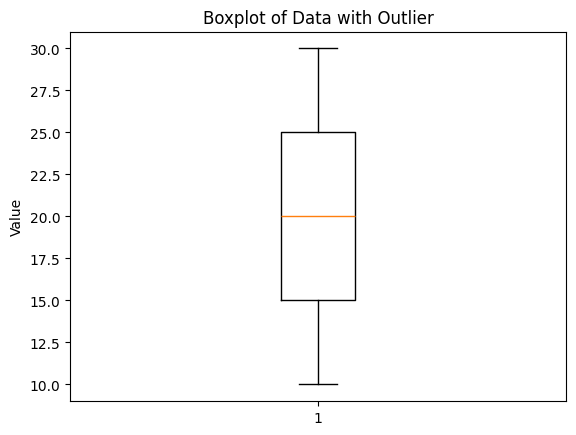

In [29]:
# example
data_with_outlier=[10,12,15,18,20,22,25,28,30,100]
plt.boxplot(data_with_outlier)
plt.title("Boxplot of Data with Outlier")
plt.ylabel("Value")
plt.show()

In [30]:
# Side-by-Side Boxplot

## create dataframe
df=pd.DataFrame({
    "Department":[
        "CSE","CSE","CSE","CSE","CSE",
        "ECE","ECE","ECE","ECE","ECE"
    ],
    "Marks":[
        78,85,92,88,76,
        65,72,80,75,68
    ]

})

df

,Department,Marks
0,CSE,78
1,CSE,85
2,CSE,92
3,CSE,88
4,CSE,76
5,ECE,65
6,ECE,72
7,ECE,80
8,ECE,75
9,ECE,68


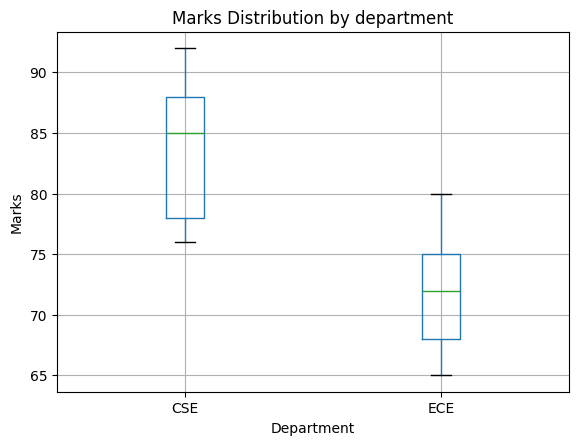

In [31]:
df.boxplot(
    column="Marks",
    by="Department"
)

plt.title("Marks Distribution by department")
plt.suptitle("")
plt.xlabel("Department")
plt.ylabel("Marks")
plt.show()

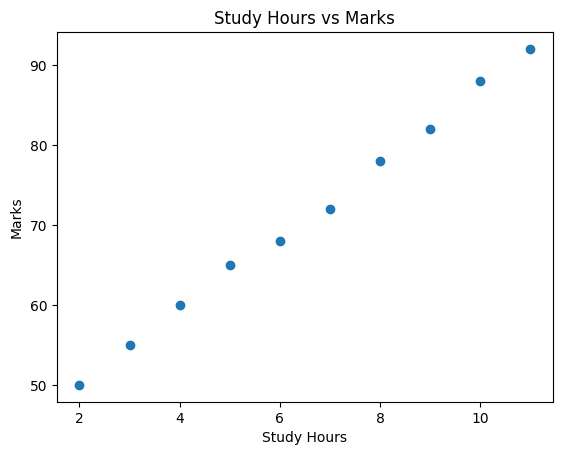

In [33]:
# Scatterplot

study_hours=[2,3,4,5,6,7,8,9,10,11]
marks=[50,55,60,65,68,72,78,82,88,92]

plt.scatter(study_hours,marks)
plt.title("Study Hours vs Marks")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.show()

In [34]:
# covariance
np.cov(study_hours,marks)

array([[  9.16666667,  42.33333333],
       [ 42.33333333, 196.        ]])

In [35]:
## To get the covariance between the two variables:
np.cov(study_hours, marks)[0, 1]

np.float64(42.33333333333333)

In [36]:
## Covariance of a variable with itself(variance)
np.cov(study_hours, study_hours)[0, 1]

np.float64(9.166666666666666)

In [37]:
# Covariance using pandas
df_cov=pd.DataFrame({
    "study_hours":study_hours,
    "marks":marks
})

df_cov

,study_hours,marks
0,2,50
1,3,55
2,4,60
3,5,65
4,6,68
5,7,72
6,8,78
7,9,82
8,10,88
9,11,92


In [38]:
df_cov.cov()

,study_hours,marks
study_hours,9.166667,42.333333
marks,42.333333,196.000000


In [39]:
# Understand covariance with different relationships
## Positive relationship
x=[1,2,3,4,5]
y=[2,4,6,8,10]

np.cov(x,y)[0,1]

np.float64(5.0)

In [40]:
## Negative relationship
x=[1,2,3,4,5]
y=[10,8,6,5,4]
np.cov(x,y)[0,1]

np.float64(-3.75)

In [41]:
## Little/no linear relationship
x=[1,2,3,4,5]
y=[7,3,9,2,8]
np.cov(x,y)[0,1]

np.float64(0.25)

In [42]:
# Correlation
np.corrcoef(study_hours,marks)


array([[1.        , 0.99873142],
       [0.99873142, 1.        ]])

In [43]:
## Extract the correlation:

np.corrcoef(study_hours, marks)[0, 1]

np.float64(0.9987314155074841)

In [44]:
df_cov.corr()

,study_hours,marks
study_hours,1.000000,0.998731
marks,0.998731,1.000000


In [50]:
# Compare covariance vs correlation
covariance = df_cov["study_hours"].cov(df_cov["marks"])
print("Covariance:", covariance)
correlation = df_cov["study_hours"].corr(df_cov["marks"])
print("Correlation:", correlation)

Covariance: 42.33333333333333
Correlation: 0.9987314155074841


In [51]:
## Strong positive correlation
x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]

np.corrcoef(x, y)[0, 1]

np.float64(0.9999999999999999)

In [52]:
## Strong negative correlation
x = [1, 2, 3, 4, 5]
y = [10, 8, 6, 4, 2]

np.corrcoef(x, y)[0, 1]

np.float64(-0.9999999999999999)

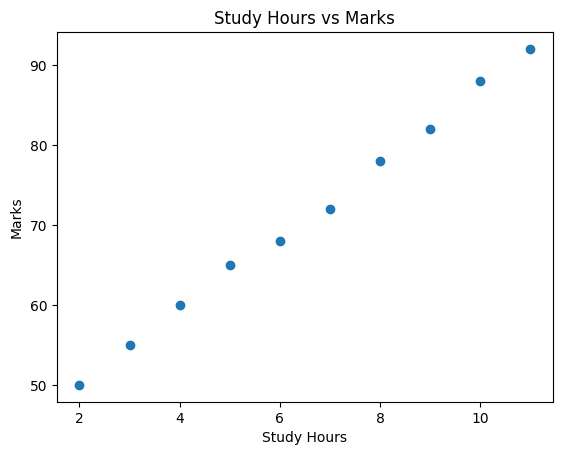

In [53]:
## Visualize correlation
plt.scatter(study_hours, marks)

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Marks")

plt.show()

In [54]:
## Correlation Matrix
df = pd.DataFrame({
    "Study_Hours": [2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    "Sleep_Hours": [8, 7, 7, 6, 7, 6, 6, 5, 6, 5],
    "Marks": [50, 55, 60, 65, 68, 72, 78, 82, 88, 92]
})

df

,Study_Hours,Sleep_Hours,Marks
0,2,8,50
1,3,7,55
2,4,7,60
3,5,6,65
4,6,7,68
5,7,6,72
6,8,6,78
7,9,5,82
8,10,6,88
9,11,5,92


In [55]:
df.corr()

,Study_Hours,Sleep_Hours,Marks
Study_Hours,1.000000,-0.870388,0.998731
Sleep_Hours,-0.870388,1.000000,-0.870045
Marks,0.998731,-0.870045,1.000000


# One complete Mini Analysis

In [56]:
df=pd.DataFrame({
    "Study_hours":[2,3,4,5,6,7,8,9,10,11],
    "Sleep_hours":[8,7,7,6,7,6,6,5,6,5],
    "Marks":[50,55,60,65,68,72,78,82,88,92]
})

df.describe()

,Study_hours,Sleep_hours,Marks
count,10.00000,10.000000,10.00
mean,6.50000,6.300000,71.00
std,3.02765,0.948683,14.00
min,2.00000,5.000000,50.00
25%,4.25000,6.000000,61.25
50%,6.50000,6.000000,70.00
75%,8.75000,7.000000,81.00
max,11.00000,8.000000,92.00


In [57]:
## correlation
df.corr()

,Study_hours,Sleep_hours,Marks
Study_hours,1.000000,-0.870388,0.998731
Sleep_hours,-0.870388,1.000000,-0.870045
Marks,0.998731,-0.870045,1.000000


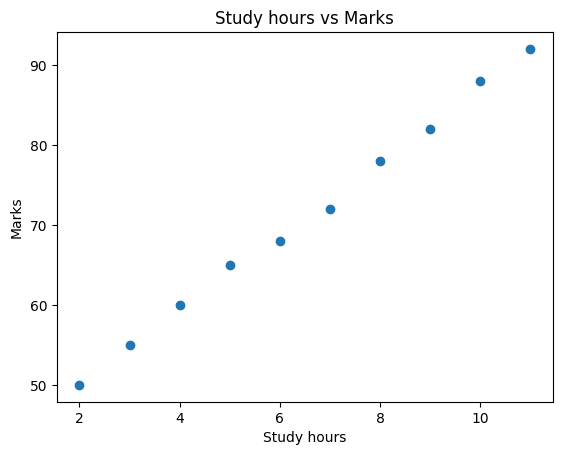

In [58]:
## scatterplot
plt.scatter(df["Study_hours"],df["Marks"])
plt.xlabel("Study hours")
plt.ylabel("Marks")
plt.title("Study hours vs Marks")
plt.show()

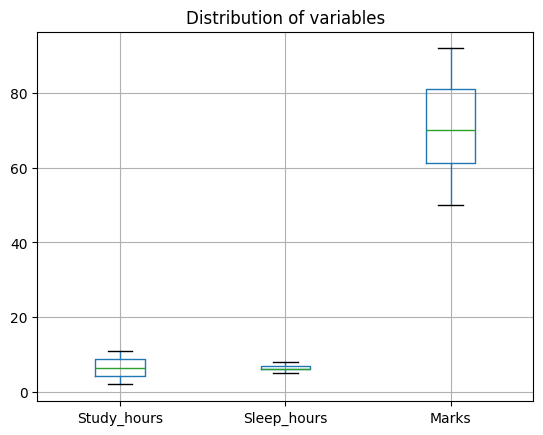

In [59]:
## Boxplot
df.boxplot()
plt.title("Distribution of variables")
plt.show()

### Key Findings

1. The median marks are 70.00.
2. Q1 of marks is 61.25.
3. Q3 of marks is 81.00.
4. The IQR of marks is 11.00.
5. There are 0 potential outliers.
6. Study hours and marks have a positive correlation.
7. The covariance between study hours and marks is 42.33333333333333(positive).
8. Correlation is more useful than covariance for comparing relationship strength because degree.
9. From the scatterplot, I observe - both study hours and marks are positively correlated.
10. Correlation does not necessarily mean causation.